In [1]:
import pandas as pd   

In [2]:
df = pd.read_csv("../Dataset/indian_banking_transactions.csv")

In [3]:
df.shape

(550000, 20)

In [4]:
df.columns

Index(['transaction_id', 'customer_id', 'transaction_date', 'transaction_time',
       'account_type', 'transaction_type', 'transaction_amount',
       'transaction_direction', 'account_balance', 'merchant_category',
       'state', 'credit_score', 'has_loan', 'loan_type', 'emi_amount',
       'transaction_status', 'channel', 'kyc_status', 'is_fraud',
       'transaction_hour'],
      dtype='str')

In [5]:
df.head()

,transaction_id,customer_id,transaction_date,transaction_time,account_type,transaction_type,transaction_amount,transaction_direction,account_balance,merchant_category,state,credit_score,has_loan,loan_type,emi_amount,transaction_status,channel,kyc_status,is_fraud,transaction_hour
0,TXN000000001,CUST015796,2019-01-01,15:28,Current,UPI,1820.17,Debit,609365.31,Food & Dining,Maharashtra,764,0,NaN,0.00,Success,Branch,Verified,0,15
1,TXN000000002,CUST000861,2019-01-01,03:00,Current,UPI,392.67,Credit,14451.14,Education,West Bengal,630,0,NaN,0.00,Success,Mobile_App,Verified,0,3
2,TXN000000003,CUST076821,2019-01-01,18:03,Fixed Deposit,POS,1255.97,Debit,47621.87,Utilities,Punjab,813,1,Home,1433.91,Success,Mobile_App,Verified,0,18
3,TXN000000004,CUST054887,2019-01-01,08:03,Savings,UPI,2580.68,Debit,34467.85,Travel,Karnataka,628,1,Personal,6280.35,Success,API,Verified,0,8
4,TXN000000005,CUST006266,2019-01-01,14:23,Fixed Deposit,UPI,2573.80,Debit,26617.40,Utilities,West Bengal,767,0,NaN,0.00,Success,API,Verified,0,14


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 550000 entries, 0 to 549999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   transaction_id         550000 non-null  str    
 1   customer_id            550000 non-null  str    
 2   transaction_date       550000 non-null  str    
 3   transaction_time       550000 non-null  str    
 4   account_type           550000 non-null  str    
 5   transaction_type       550000 non-null  str    
 6   transaction_amount     550000 non-null  float64
 7   transaction_direction  550000 non-null  str    
 8   account_balance        550000 non-null  float64
 9   merchant_category      550000 non-null  str    
 10  state                  550000 non-null  str    
 11  credit_score           550000 non-null  int64  
 12  has_loan               550000 non-null  int64  
 13  loan_type              172866 non-null  str    
 14  emi_amount             550000 non-null  float64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

transaction_id                0
customer_id                   0
transaction_date              0
transaction_time              0
account_type                  0
transaction_type              0
transaction_amount            0
transaction_direction         0
account_balance               0
merchant_category             0
state                         0
credit_score                  0
has_loan                      0
loan_type                377134
emi_amount                    0
transaction_status            0
channel                       0
kyc_status                    0
is_fraud                      0
transaction_hour              0
dtype: int64

In [9]:
df['has_loan'].value_counts()

has_loan
0    357712
1    192288
Name: count, dtype: int64

In [10]:
pd.crosstab(df['has_loan'], df['loan_type'], dropna=False)

loan_type,Auto,Business,Education,Gold,Home,Personal,NaN
has_loan,,,,,,,
0,0,0,0,0,0,0,357712
1,29219,28863,19074,9648,38252,47810,19422


In [11]:
df['is_fraud'].value_counts()

is_fraud
0    545127
1      4873
Name: count, dtype: int64

In [12]:
df.describe()

,transaction_amount,account_balance,credit_score,has_loan,emi_amount,is_fraud,transaction_hour
count,5.500000e+05,5.500000e+05,550000.000000,550000.000000,550000.000000,550000.00000,550000.000000
mean,2.990709e+04,8.455012e+04,599.807009,0.349615,2365.859974,0.00886,11.504431
std,1.396101e+05,1.709146e+05,173.054597,0.476849,4973.546080,0.09371,6.924499
min,2.400000e+00,5.000000e+02,300.000000,0.000000,0.000000,0.00000,0.000000
25%,7.630375e+02,1.515778e+04,450.000000,0.000000,0.000000,0.00000,6.000000
50%,2.035735e+03,3.642287e+04,600.000000,0.000000,0.000000,0.00000,11.000000
75%,8.557497e+03,8.760704e+04,750.000000,1.000000,3115.030000,0.00000,17.000000
max,1.000000e+07,5.000000e+06,899.000000,1.000000,153325.740000,1.00000,23.000000


In [13]:
df.loc[(df['has_loan'] == 0) & (df['loan_type'].isna()), 'loan_type'] = 'No loan'

In [14]:
df['loan_type'].value_counts(dropna=False)

loan_type
No loan      357712
Personal      47810
Home          38252
Auto          29219
Business      28863
NaN           19422
Education     19074
Gold           9648
Name: count, dtype: int64

In [15]:
df.loc[(df['has_loan'] ==  1) & (df['loan_type'].isna()), 'loan_type'] = 'Unknown'

In [16]:
df.dtypes

transaction_id               str
customer_id                  str
transaction_date             str
transaction_time             str
account_type                 str
transaction_type             str
transaction_amount       float64
transaction_direction        str
account_balance          float64
merchant_category            str
state                        str
credit_score               int64
has_loan                   int64
loan_type                    str
emi_amount               float64
transaction_status           str
channel                      str
kyc_status                   str
is_fraud                   int64
transaction_hour           int64
dtype: object

In [17]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

In [18]:
df.dtypes

transaction_id                      str
customer_id                         str
transaction_date         datetime64[us]
transaction_time                    str
account_type                        str
transaction_type                    str
transaction_amount              float64
transaction_direction               str
account_balance                 float64
merchant_category                   str
state                               str
credit_score                      int64
has_loan                          int64
loan_type                           str
emi_amount                      float64
transaction_status                  str
channel                             str
kyc_status                          str
is_fraud                          int64
transaction_hour                  int64
dtype: object

In [19]:
df['transaction_date'].min(),df['transaction_date'].max()

(Timestamp('2019-01-01 00:00:00'), Timestamp('2024-01-01 00:00:00'))

In [20]:
df['transaction_status'].value_counts()

transaction_status
Success     506247
Failed       21905
Reversed     11019
Pending      10829
Name: count, dtype: int64

In [21]:
df['transaction_type'].value_counts()

transaction_type
UPI               153986
IMPS               77038
NEFT               66615
POS                60278
ATM_Withdrawal     55106
Net_Banking        38458
RTGS               32964
Auto_Debit         27418
Cheque             21711
Credit_Card        16426
Name: count, dtype: int64

In [22]:
df['transaction_direction'].value_counts()

transaction_direction
Debit     370394
Credit    179606
Name: count, dtype: int64

In [23]:
df['account_type'].value_counts()

account_type
Savings          219651
Current          137648
Salary           110067
NRI               43746
Fixed Deposit     38888
Name: count, dtype: int64

In [24]:
df['channel'].value_counts()

channel
Mobile_App      208368
Web             121010
ATM              66177
POS_Terminal     60853
Branch           54957
API              38635
Name: count, dtype: int64

In [25]:
df['kyc_status'].value_counts()

kyc_status
Verified    483457
Pending      44288
Expired      22255
Name: count, dtype: int64

In [26]:
df['merchant_category'].value_counts()

merchant_category
Retail           66180
Food & Dining    54776
E-Commerce       54767
Travel           44177
Salary           43937
Peer Transfer    38753
Utilities        38575
Healthcare       33015
Entertainment    32997
Government       27508
Investment       27380
Education        27359
Insurance        22020
Fuel             21929
Real Estate      16627
Name: count, dtype: int64

In [27]:
df['state'].value_counts()

state
Maharashtra    98911
Karnataka      76659
Tamil Nadu     71747
Delhi          66114
Gujarat        54798
Telangana      49610
West Bengal    43950
Rajasthan      38725
UP             27414
Punjab         22072
Name: count, dtype: int64

In [28]:
df['credit_score'].describe()

count    550000.000000
mean        599.807009
std         173.054597
min         300.000000
25%         450.000000
50%         600.000000
75%         750.000000
max         899.000000
Name: credit_score, dtype: float64

In [29]:
df['transaction_amount'].describe()

count    5.500000e+05
mean     2.990709e+04
std      1.396101e+05
min      2.400000e+00
25%      7.630375e+02
50%      2.035735e+03
75%      8.557497e+03
max      1.000000e+07
Name: transaction_amount, dtype: float64

In [30]:
df['account_balance'].describe()

count    5.500000e+05
mean     8.455012e+04
std      1.709146e+05
min      5.000000e+02
25%      1.515778e+04
50%      3.642287e+04
75%      8.760704e+04
max      5.000000e+06
Name: account_balance, dtype: float64

In [31]:
df['emi_amount'].describe()

count    550000.000000
mean       2365.859974
std        4973.546080
min           0.000000
25%           0.000000
50%           0.000000
75%        3115.030000
max      153325.740000
Name: emi_amount, dtype: float64

In [32]:
df[['transaction_amount', 'emi_amount', 'account_balance']].min()

transaction_amount      2.4
emi_amount              0.0
account_balance       500.0
dtype: float64

In [33]:
df.isnull().sum().sum()

np.int64(0)

# EDA (Exploratory Data Analysis)

##Question 1: What is the total number of transactions in the dataset?

In [34]:
df['transaction_id'].count()

np.int64(550000)

##Question 2: Which transaction type is used most frequently?

In [35]:
df['transaction_type'].value_counts()

transaction_type
UPI               153986
IMPS               77038
NEFT               66615
POS                60278
ATM_Withdrawal     55106
Net_Banking        38458
RTGS               32964
Auto_Debit         27418
Cheque             21711
Credit_Card        16426
Name: count, dtype: int64

##Question 3: What is the total transaction amount?

In [36]:
df['transaction_amount'].sum()

np.float64(16448901663.56)

##Question 4 : Which merchant category has the highest number of transactions?

In [37]:
df['merchant_category'].value_counts()

merchant_category
Retail           66180
Food & Dining    54776
E-Commerce       54767
Travel           44177
Salary           43937
Peer Transfer    38753
Utilities        38575
Healthcare       33015
Entertainment    32997
Government       27508
Investment       27380
Education        27359
Insurance        22020
Fuel             21929
Real Estate      16627
Name: count, dtype: int64

##Question 5: Which state has the highest number of transactions?

In [38]:
df['state'].value_counts()

state
Maharashtra    98911
Karnataka      76659
Tamil Nadu     71747
Delhi          66114
Gujarat        54798
Telangana      49610
West Bengal    43950
Rajasthan      38725
UP             27414
Punjab         22072
Name: count, dtype: int64

##Question 6: Which channel is most commonly used for transactions?

In [39]:
df['channel'].value_counts()

channel
Mobile_App      208368
Web             121010
ATM              66177
POS_Terminal     60853
Branch           54957
API              38635
Name: count, dtype: int64

##Question 7: How are transactions distributed between Debit and Credit?

In [40]:
df['transaction_direction'].value_counts()

transaction_direction
Debit     370394
Credit    179606
Name: count, dtype: int64

##Question 8: How many transactions are fraudulent and non-fraudulent?

In [41]:
df['is_fraud'].value_counts()

is_fraud
0    545127
1      4873
Name: count, dtype: int64

##Question 9: Which transaction type has the highest number of fraudulent transactions?

In [42]:
df[df['is_fraud'] == 1] ['transaction_type'].value_counts()

transaction_type
UPI               1211
IMPS               624
RTGS               611
NEFT               581
POS                481
ATM_Withdrawal     456
Net_Banking        326
Cheque             256
Auto_Debit         187
Credit_Card        140
Name: count, dtype: int64

##Question 10: Which transaction channel has the highest number of fraudulent transactions?

In [43]:
df[df['is_fraud'] == 1]['channel'].value_counts()

channel
Mobile_App      1809
Web             1080
ATM              561
POS_Terminal     557
Branch           520
API              346
Name: count, dtype: int64

##Question 11: Which merchant category has the most fraudulent transactions?

In [44]:
df[df['is_fraud'] == 1]['merchant_category'].value_counts()

merchant_category
Retail           594
E-Commerce       502
Food & Dining    471
Salary           396
Travel           388
Peer Transfer    362
Utilities        323
Entertainment    300
Healthcare       300
Investment       252
Education        236
Government       214
Fuel             201
Insurance        191
Real Estate      143
Name: count, dtype: int64

##Question 12: At what transaction hours are fraudulent transactions more common?

In [45]:
df[df['is_fraud'] == 1]['transaction_hour'].value_counts().sort_index()

transaction_hour
0     217
1     182
2     192
3     211
4     202
5     193
6     213
7     218
8     197
9     202
10    233
11    196
12    198
13    180
14    209
15    217
16    216
17    199
18    199
19    204
20    182
21    215
22    192
23    206
Name: count, dtype: int64

##Visualization 1: Number of Transactions by Transaction Type

<Axes: xlabel='transaction_type'>

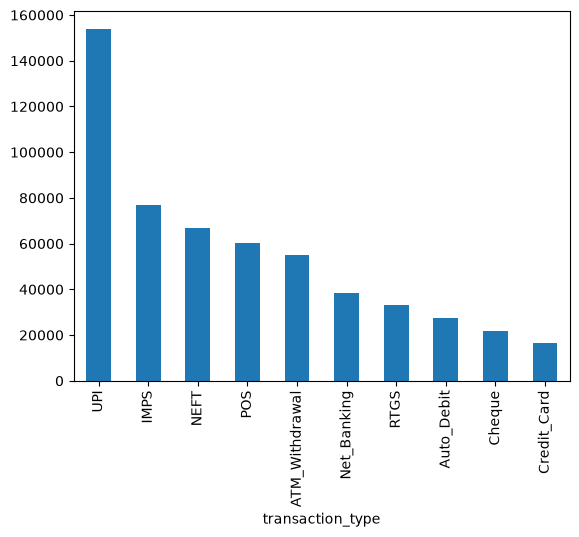

In [46]:
df['transaction_type'].value_counts().plot(kind='bar')

##Visualization 2: Number of Transactions by Merchant Category

<Axes: xlabel='merchant_category'>

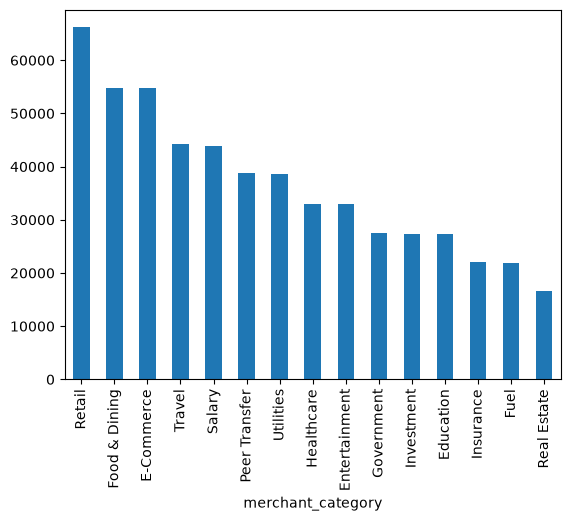

In [47]:
df['merchant_category'].value_counts().plot(kind='bar')

##Visualization 3: Number of Transactions by State

<Axes: xlabel='state'>

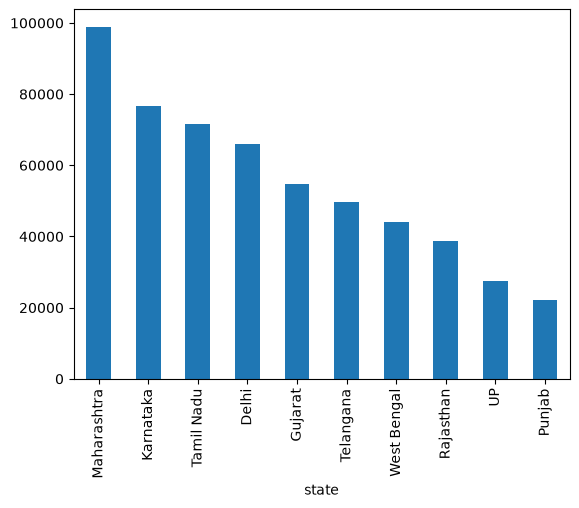

In [48]:
df['state'].value_counts().plot(kind='bar')

##Visualization 4: Debit vs Credit Transactions

<Axes: >

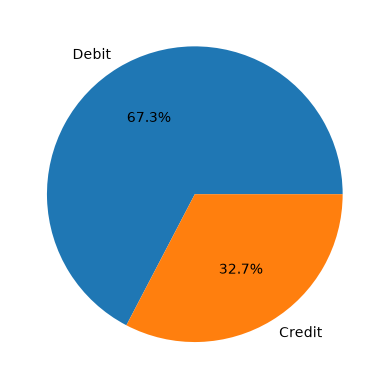

In [49]:
df['transaction_direction'].value_counts().plot(kind='pie', autopct='%1.1f%%')

##Visualization 5: Fraudulent Transactions by Transaction Type

<Axes: xlabel='transaction_type'>

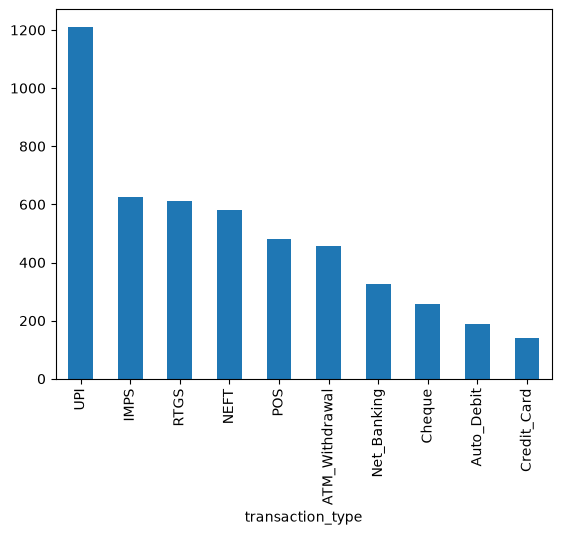

In [50]:
df[df['is_fraud'] == 1]['transaction_type'].value_counts().plot(kind='bar')

##Visualization 6: Fraudulent Transactions by Hour

<Axes: xlabel='transaction_hour'>

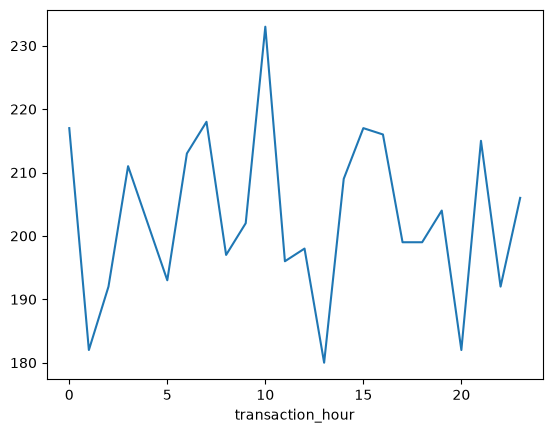

In [51]:
df[df['is_fraud'] == 1]['transaction_hour'].value_counts().sort_index().plot(kind='line')

#### Suspicious Activity - Step 1: High-Value Transactions

#### Question 1: What is the 99th percentile of the transaction amount?

In [52]:
df['transaction_amount'].quantile(0.99)

np.float64(530534.6678000005)

#### Suspicious Activity - Step 2: High-Value Transactions

#### Question 2: How many transactions are above the 99th percentile amount?

In [53]:
df[df['transaction_amount']>530534.6678000005].shape[0]

5500

#### Suspicious Activity - Step 3: Unusual Transaction Hours

#### Question 3: How many transactions occur during late-night hours (12 AM to 5 AM)?

In [54]:
df[df['transaction_hour'].between(0, 5)].shape[0]

137167

#### Suspicious Activity - Step 4: Fraudulent Late-Night Transactions

#### Question 4: How many fraudulent transactions occurred during late-night hours (12 AM to 5 AM)?

In [55]:
df[(df['is_fraud'] == 1) & (df['transaction_hour'].between(0, 5))].shape[0]

1197

#### Suspicious Activity - Step 5: High-Value Fraudulent Transactions

#### Question 5: How many fraudulent transactions are above the 99th percentile amount?

In [56]:
df[(df['is_fraud'] == 1) & (df['transaction_amount'] > 530534.6678)].shape[0]

454

#### Suspicious Activity - Step 6: Failed Transactions

#### Question 6: How many fraudulent transactions have a failed transaction status?

In [57]:
df[(df['is_fraud'] == 1) & (df['transaction_status'] == 'Failed')].shape[0]

205

#### Final Step: Export Cleaned Dataset

In [58]:
df.to_csv("../Dataset/cleaned_bank_transcations.csv", index=False)

In [59]:
df['loan_type'].isnull().sum()

np.int64(0)